# Анализ финального датасета мемов

В этом ноутбуке мы анализируем собранный и очищенный датасет мемов (`processed/final_dataset_text.csv`).
Данные прошли через:
1. Сбор (Bing, Telegram, HF, Kaggle).
2. OCR (PaddleOCR v3).
3. Фильтрацию матов и мусора.

In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Настройки графиков
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# === КОНФИГ ===
DATASET_PATH = Path("../data/processed/final_dataset_text.csv")



In [2]:
# 1. Загрузка данных
df = pd.read_csv(DATASET_PATH)

print(f"Всего строк: {len(df)}")
print("Колонки:", df.columns.tolist())
df.head()

Всего строк: 16080
Колонки: ['filename', 'source_path', 'ocr_text', 'confidence', 'source_type']


,filename,source_path,ocr_text,confidence,source_type
0,hf_notlain_00008.jpg,data/raw/hf_memes/images/hf_notlain_00008.jpg,NaN,0.0,huggingface
1,hf_notlain_00020.jpg,data/raw/hf_memes/images/hf_notlain_00020.jpg,NaN,0.0,huggingface
2,hf_notlain_00034.jpg,data/raw/hf_memes/images/hf_notlain_00034.jpg,NaN,0.0,huggingface
3,hf_notlain_00222.jpg,data/raw/hf_memes/images/hf_notlain_00222.jpg,NaN,0.0,huggingface
4,hf_notlain_00236.jpg,data/raw/hf_memes/images/hf_notlain_00236.jpg,NaN,0.0,huggingface


In [3]:
# 2. Проверка пропусков и типов
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16080 entries, 0 to 16079
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   filename     16080 non-null  object 
 1   source_path  16080 non-null  object 
 2   ocr_text     6043 non-null   object 
 3   confidence   16080 non-null  float64
 4   source_type  16080 non-null  object 
dtypes: float64(1), object(4)
memory usage: 628.3+ KB


## Статистика источников

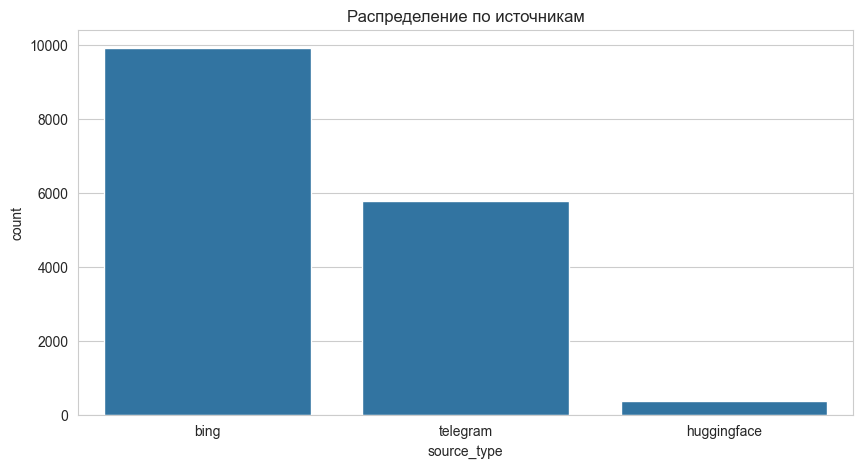

source_type
bing           9926
telegram       5792
huggingface     362
Name: count, dtype: int64

In [4]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='source_type', order=df['source_type'].value_counts().index)
plt.title("Распределение по источникам")
plt.show()

df['source_type'].value_counts()

## OCR Confidence (Уверенность модели)

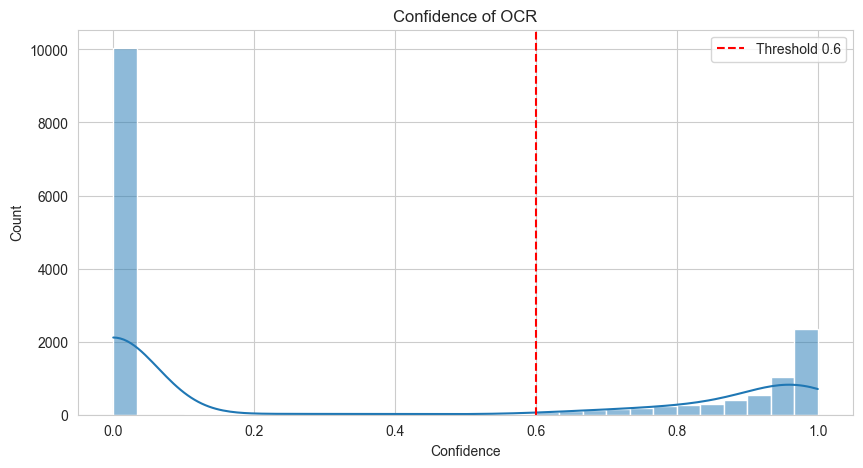

Картинок без текста: 10037 (62.4%)


In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(df['confidence'], bins=30, kde=True)
plt.title("Confidence of OCR")
plt.xlabel("Confidence")
plt.axvline(0.6, color='r', linestyle='--', label='Threshold 0.6')
plt.legend()
plt.show()

# Сколько пустых
empty_count = len(df[df['confidence'] == 0])
print(f"Картинок без текста: {empty_count} ({empty_count/len(df):.1%})")

## Примеры текстов
Посмотрим на случайные тексты с высокой уверенностью.

In [6]:
pd.set_option('display.max_colwidth', None)
df[df['confidence'] > 0.8][['ocr_text', 'confidence', 'source_type']].sample(10)

,ocr_text,confidence,source_type
13467,lvidalo Yа No omi ero Nada,0.8427,telegram
9327,Заявление Отказано в предоставлении услуги 17.01.24 B 23:20 Программа «Альтушка с Госуслуг»,0.9729,bing
8726,"Me looking down on you for not knowing a fact I learned yesterday BigKidProblems BKP @BigKidProblems Trying to budget my monthly expenses. Car:$300 Phone: $150 Things I buy online when I'm sad: $3,75 Utilities: $150",0.9815,bing
8295,Когда обеденный перерыв закончился И тебе еще осталось работать 30 нет,0.9101,bing
7843,When you're in Rome and you release your mixtape,0.9899,bing
7186,"She went very peacefully without suffering, as if falling asleep while feeling the warmth of my hands petting her.",0.9906,bing
6050,El Arroys Austin BEFORE E EXCEPT AFTER C? WEIRD,0.9430,bing
7252,super tingley ep foot mcdonalads sprite,0.9928,bing
12800,DRONOS ЕБЕЙШИЙ,0.8880,telegram
13971,11,0.8814,telegram


In [8]:
df_empty = df[(df['confidence'] == 0.0)]
print(df_empty.shape)

df_not_empty = df[df['confidence'] > 0]
print(df_not_empty.shape)

(10037, 5)
(6043, 5)


при t = 0.60 кол-во объектов 5776
при t = 0.62 кол-во объектов 5730
при t = 0.64 кол-во объектов 5669
при t = 0.66 кол-во объектов 5601
при t = 0.68 кол-во объектов 5516
при t = 0.71 кол-во объектов 5438
при t = 0.73 кол-во объектов 5347
при t = 0.75 кол-во объектов 5230
при t = 0.77 кол-во объектов 5110
при t = 0.79 кол-во объектов 4972
при t = 0.81 кол-во объектов 4803
при t = 0.83 кол-во объектов 4638
при t = 0.85 кол-во объектов 4460
при t = 0.87 кол-во объектов 4220
при t = 0.89 кол-во объектов 3959
при t = 0.92 кол-во объектов 3683
при t = 0.94 кол-во объектов 3299
при t = 0.96 кол-во объектов 2729
при t = 0.98 кол-во объектов 1430
при t = 1.00 кол-во объектов 0


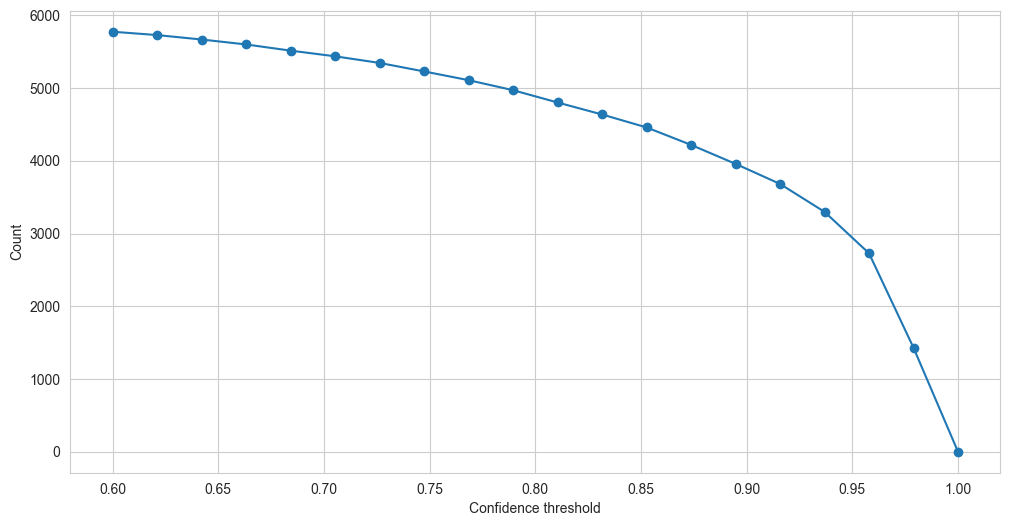

In [ ]:
import numpy as np
t = []
cnt = []
for treshold in np.linspace(0.6,1.00, 20):
    len_df = len(df_not_empty[df_not_empty['confidence'] >=treshold])
    cnt.append(len_df)
    t.append(treshold)
    print(f"при t = {treshold:.2f} кол-во объектов {len_df}")

plt.plot(t, cnt, marker='o')
plt.xlabel("Confidence threshold")
plt.ylabel("Count")
plt.show()

### Доп анализ 


In [13]:
df.columns

Index(['filename', 'source_path', 'ocr_text', 'confidence', 'source_type'], dtype='object')

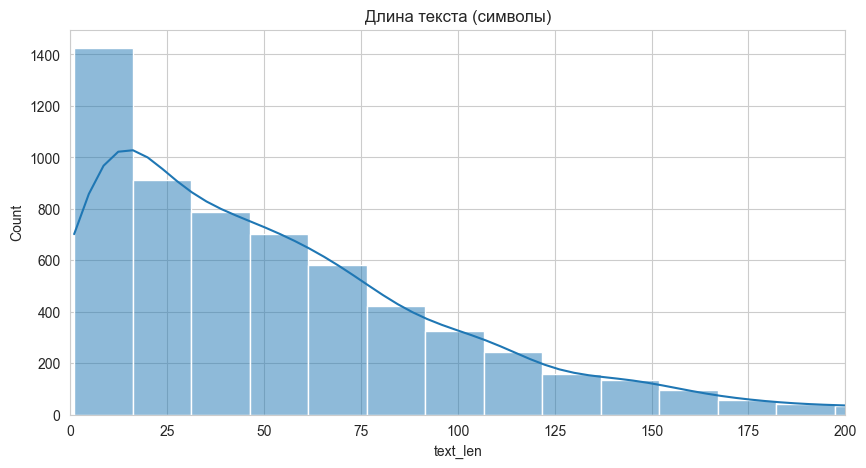

Средняя длина: 58.12775111699487


In [ ]:
# Колонка с длиной текста
df['text_len'] = df['ocr_text'].fillna("").apply(len)

plt.figure(figsize=(10, 5))
sns.histplot(df[df['text_len'] > 0]['text_len'], bins=50, kde=True)
plt.title("Длина текста (символы)")
plt.xlim(0, 200) # Ограничим до 200 символов для наглядности
plt.show()

print("Средняя длина:", df[df['text_len'] > 0]['text_len'].mean())

In [10]:
!pip install wordcloud

  Using cached wordcloud-1.9.6-cp313-cp313-macosx_11_0_arm64.whl.metadata (3.4 kB)
Using cached wordcloud-1.9.6-cp313-cp313-macosx_11_0_arm64.whl (168 kB)

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


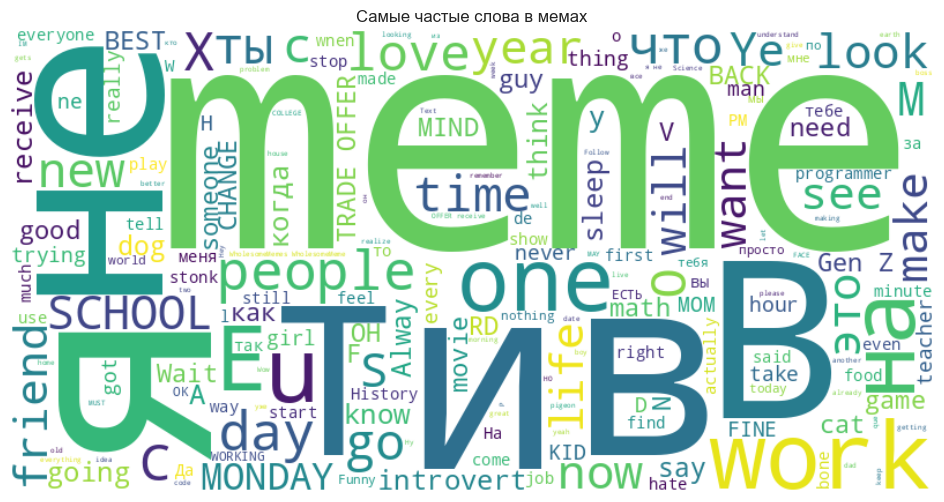

In [11]:
from wordcloud import WordCloud

text_all = " ".join(df['ocr_text'].dropna().astype(str))

wc = WordCloud(width=800, height=400, background_color='white').generate(text_all)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.title("Самые частые слова в мемах")
plt.show()

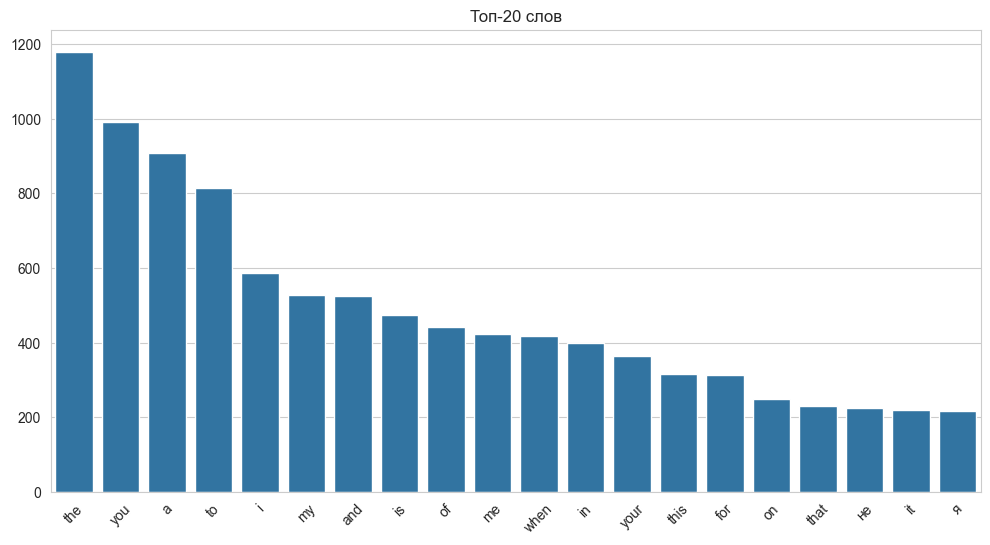

In [12]:
from collections import Counter

words = text_all.lower().split()
counter = Counter(words)
most_common = counter.most_common(20)

x, y = zip(*most_common)
plt.figure(figsize=(12, 6))
sns.barplot(x=list(x), y=list(y))
plt.title("Топ-20 слов")
plt.xticks(rotation=45)
plt.show()